# How to use
pip  install -r requirements.txt

In [4]:
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt

In [5]:
from pathlib import Path

movies_path = Path("..") / "data" / "movies_2026.csv"
movies_df = pd.read_csv(movies_path, encoding="latin-1")
movies_df.head()


,id,budget,genres,homePage,productionCompany,productionCompanyCountry,productionCountry,revenue,runtime,video,...,releaseDate,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,1627085,0.0,Drama|Crime,NaN,NaN,NaN,NaN,0.0,95,False,...,2026-02-01,0.0,0,2,0,0,8,2.0,5.0,2026.0
1,1626914,0.0,Animation,NaN,NaN,NaN,NaN,0.0,3,False,...,2026-02-01,0.0,0,1,0,0,4,0.0,0.0,2026.0
2,1626898,0.0,Animation,NaN,NaN,NaN,NaN,0.0,2,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0
3,1626808,0.0,Thriller|Mystery|Documentary,NaN,NaN,NaN,NaN,0.0,5,False,...,2026-02-01,0.0,0,3,0,0,7,0.0,0.0,2026.0
4,1626678,0.0,Animation,NaN,NaN,NaN,NaN,0.0,12,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0


In [6]:
movies_df.columns

Index(['id', 'budget', 'genres', 'homePage', 'productionCompany',
       'productionCompanyCountry', 'productionCountry', 'revenue', 'runtime',
       'video', 'director', 'actors', 'actorsPopularity', 'actorsCharacter',
       'originalTitle', 'title', 'originalLanguage', 'popularity',
       'releaseDate', 'voteAvg', 'voteCount', 'genresAmount',
       'productionCoAmount', 'productionCountriesAmount', 'actorsAmount',
       'castWomenAmount', 'castMenAmount', 'releaseYear'],
      dtype='object')

In [7]:
# 4.3 Pelicula con mas votos
most_votes = movies_df.loc[movies_df['voteCount'].idxmax()]
most_votes_title = most_votes['title']
print(most_votes_title)

Inception


In [8]:
# 4.4 Peor pelicula según votos
worst_by_votes = movies_df.loc[movies_df['voteCount'].idxmin()]
worst_by_votes_title = worst_by_votes['title']
print(worst_by_votes_title)

Immersed


In [27]:
max_year = movies_df['releaseYear'].max()
print(max_year)

2026.0


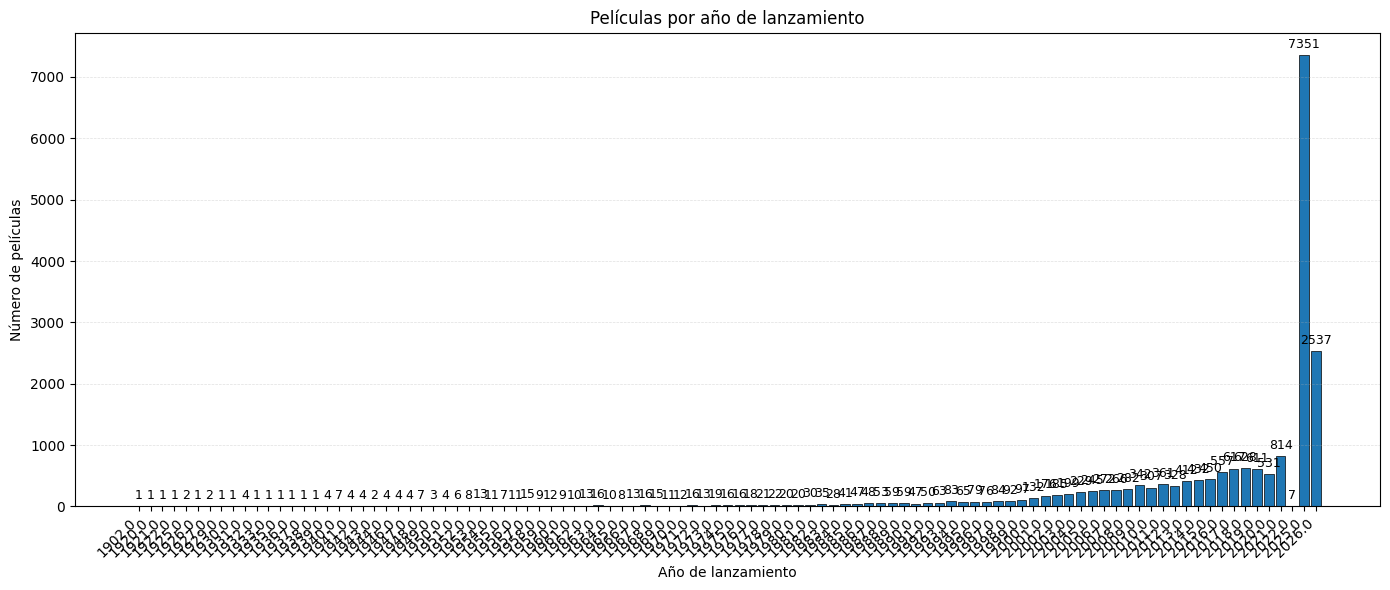

In [26]:
# 4.5 Peliculas por año, grafica de barras
pltdf = movies_df['releaseYear'].value_counts().sort_index()
plt.figure(figsize=(14, 6))
bars = plt.bar(
    pltdf.index.astype(str),
    pltdf.values,
    edgecolor="black",
    linewidth=0.5
)


plt.xlabel('Año de lanzamiento')
plt.ylabel('Número de películas')
plt.title('Películas por año de lanzamiento')
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.4)
plt.xticks(rotation=45, ha='right')
plt.bar_label(bars, padding=3, fontsize=9)
plt.tight_layout()
plt.show()

In [11]:
# 4.6 Genero principal de las 20 peliculas mas recientes
last_20_movies = movies_df.sort_values(by='releaseYear', ascending=False).head(20)
primary_genres = last_20_movies['genres'].str.split('|').str[0].fillna('No genre')
print(primary_genres.value_counts())
print("El gnero principal de las 20 peliculas mas recientes es: ", primary_genres.value_counts().idxmax())

genres
Drama          6
No genre       4
Documentary    3
Comedy         3
Music          2
Thriller       1
Horror         1
Name: count, dtype: int64
El gnero principal de las 20 peliculas mas recientes es:  Drama


[Text(0, 3, '6'),
 Text(0, 3, '4'),
 Text(0, 3, '3'),
 Text(0, 3, '3'),
 Text(0, 3, '2'),
 Text(0, 3, '1'),
 Text(0, 3, '1')]

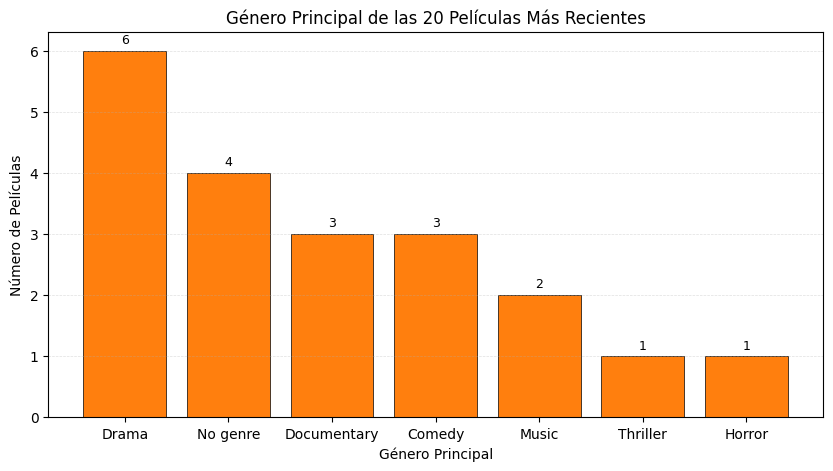

In [12]:
# Grafico de barras para las 20 peliculas mas recientes y sus generos
plt.figure(figsize=(10, 5))
bars = plt.bar(primary_genres.value_counts().index, primary_genres.value_counts().values, color="#ff7f0e", edgecolor="black", linewidth=0.5)
plt.xlabel('Género Principal')
plt.ylabel('Número de Películas')
plt.title('Género Principal de las 20 Películas Más Recientes')
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.4)
plt.bar_label(bars, padding=3, fontsize=9)

In [13]:
# Genero principal con las peliculas mas largas
longest_20_movies = movies_df.sort_values(by='runtime', ascending=False).head(20)
longest_primary_genres = longest_20_movies['genres'].str.split('|').str[0].fillna('No genre')
print(longest_primary_genres.value_counts())
print("El genero principal de las peliculas mas largas es: ", longest_primary_genres.value_counts().idxmax())

genres
No genre       5
Documentary    4
Action         4
Drama          3
Music          2
Horror         1
Animation      1
Name: count, dtype: int64
El genero principal de las peliculas mas largas es:  No genre


In [15]:
# 4.7 Peliculas con mayor ganancia por genero
movies_df['profit'] = movies_df['revenue'] - movies_df['budget']
top_profit_genres = movies_df.sort_values(by='profit', ascending=False).head(20)
top_profit_primary_genres = top_profit_genres['genres'].str.split('|').str[0].fillna('No genre')
print(top_profit_primary_genres.value_counts())
print("El genero principal de las peliculas con mayor ganancia es: ", top_profit_primary_genres.value_counts().idxmax())

genres
Action             8
Adventure          3
Family             3
Science Fiction    2
Animation          2
Drama              1
Fantasy            1
Name: count, dtype: int64
El genero principal de las peliculas con mayor ganancia es:  Action


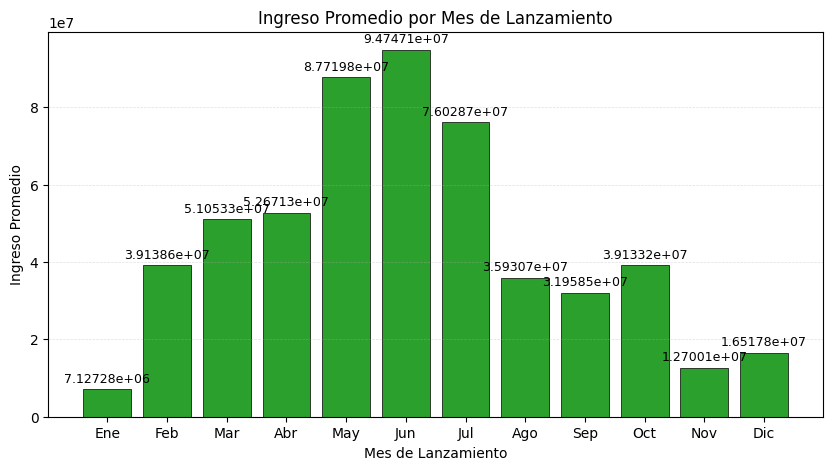

In [16]:
# 4.12 ¿Se asocian ciertos meses de lanzamiento con mejores ingresos?
movies_df['releaseMonth'] = pd.to_datetime(movies_df['releaseDate'], errors='coerce').dt.month
monthly_revenue = movies_df.groupby('releaseMonth')['revenue'].mean()
plt.figure(figsize=(10, 5))
bars = plt.bar(monthly_revenue.index, monthly_revenue.values, color="#2ca02c", edgecolor="black", linewidth=0.5)
plt.xlabel('Mes de Lanzamiento')
plt.ylabel('Ingreso Promedio')
plt.title('Ingreso Promedio por Mes de Lanzamiento')
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.4)
plt.xticks(monthly_revenue.index, ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.bar_label(bars, padding=3, fontsize=9)
plt.show()

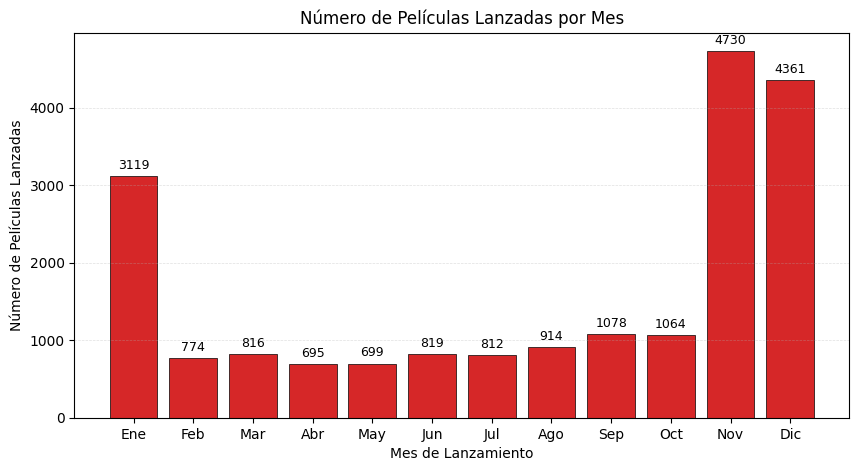

Promedio de películas lanzadas por mes: 1656.75


In [21]:
# 4.13 ¿En qué meses se han visto los lanzamientos con mejores ingresos? ¿cuantas películas, en promedio, se han lanzado por mes?
monthly_movie_count = movies_df['releaseMonth'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
bars = plt.bar(monthly_movie_count.index, monthly_movie_count.values, color="#d62728", edgecolor="black", linewidth=0.5)
plt.xlabel('Mes de Lanzamiento')
plt.ylabel('Número de Películas Lanzadas')
plt.title('Número de Películas Lanzadas por Mes')
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.4)
plt.xticks(monthly_movie_count.index, ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.bar_label(bars, padding=3, fontsize=9)
plt.show()

average_movies_per_month = monthly_movie_count.mean()
print(f"Promedio de películas lanzadas por mes: {average_movies_per_month}")
